# 7. Differential Abundance Analysis

Microbiome differential abundance analysis is challenging due to sparsity, and strong sample-to-sample variability in the data. No single statistical method performs optimally across all community structures, effect sizes, or preprocessing choices. To obtain robust and biologically meaningful results, it is therefore common practice to apply multiple complementary methods and combine their outputs.
In this notebook, we perform differential abundance analysis using ANCOM, MaAsLin2, and DESeq2:

* ANCOM-BC accounts explicitly for the compositional constraints of microbiome data, controlling false discovery rates by comparing log-ratios between taxa. It is conservative but well-suited for detecting strong, consistent shifts.
* MaAsLin2 uses multivariable linear modeling with normalization and transformation steps tailored for microbial relative abundances. It is good in handling complex metadata (covariates, continuous variables, repeated measures).
* DESeq2 models count data using negative binomial distributions and robust size-factor normalization. It is sensitive to subtle changes and performs well on raw count matrices.

Because each method captures different aspects of the data and may produce partially overlapping sets of significant features, we generate a consensus set of taxa that are consistently detected across methods. This intersection provides a more stable and reproducible set of associations, minimizing method-specific artifacts and increasing confidence in the biological interpretations [Nearing et al. (2022)].

We will perform Differential analysis for Diet (breastfed dominant, formula fed dominant and mixed), Age (4, 7 and 10 months) and Ttreatment exposure (True or False). We will perform differential analysis for diet, age, and treatment exposure, while correcting for repeated measures using host_id as a random effect (ANCOM and MaAsLin2) or blocking factor (DESeq2).

### Notebook Structure

**1.** Data Exploration  
**2.** ANCOM    
**3.** MaAsLin2  
**4.** DESeq2  
**5.** Consensus Set 

## Import data & packages

In [12]:
# 1 - Import packages
import os
import matplotlib.pyplot as plt
import pandas as pd
import qiime2 as q2
from qiime2 import Visualization
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro
from math import sqrt
import numpy as np
  
%matplotlib inline

In [13]:
# 2 - Set working directory
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/scripts").


In [14]:
# 3 - Data directories
meta_data_dir = "../data/processed/metadata"
raw_data_dir = "../data/raw"
denoised_data_dir = "../data/processed/denoising"
taxonomy_data_dir = "../data/processed/taxonomy"
diversity_data_dir = "../data/processed/diversity"
phylogeny_data_dir = "../data/processed/phylogeny"
daa_data_dir = "../data/processed/differential_abundance"
# Create the new differential abundance analysis folder

In [4]:
%%bash -s "$daa_data_dir"
mkdir -p "$1"

# 1. Data Exploration: look at feature table and data distribution

We want to have a look at the feature table to check if it is sparse (a lot of zero-values) and to have a look at the data distribution. We can see in the table that there are quite a lot of zero-values and from the violin-plot we can see that the data is not normally distributed. We additionally did the Shapiro-Wilk test to check if the data is normally distributed, since we only plotted 15 samples. Further down in the results we can see that the data indeed is not normally distributed.

In [5]:
#import and plot feature table to check for zero-values
data = q2.Artifact.load(f'{denoised_data_dir}/dada2_table.qza').view(pd.DataFrame)

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [6]:
data.head()

,35ffcc3b809d667286737d79670b8de5,d46e2205f0c6ecf67b51f83d111c509c,2c982937754e6321f861027032db80f7,99deb3c5ecb022ec05609ebd1112a557,fd44d4cb468fd7dc9b3227867714ed87,2c5e87b291147c04e1b8d1c808b1aee0,c24e0e391aa836b5eae25567c7eb89ee,9908fffab7ed4f3bec44cda2f5084d49,315ca0a729f126b941ba111a16d4d97a,945184b6386c192c0066e0a98a154780,...,2bce8615134b73991ef0e14272646791,3a5317c713023cb528a3d6ea8edaf0a3,0a764c782ff16c18e0e2bde8d46d4608,74cd5ddaf80f3aabb34845c1558d1e54,98d918d67a235038cddd3e27015d9f39,f995b00628c62422bfba901c52048e10,ef500a1b2cafbc7ea19d914cc368cba0,6871fd2ae0f5548e5b16e9cdd0f767ac,919f2dcd2712ba221a695b4a98c5651c,efaa636ca54aed7c824dd9f521028c6b
SRR8115637,12850.0,12487.0,0.0,0.0,0.0,0.0,190.0,1903.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115646,2488.0,500.0,72.0,5071.0,0.0,901.0,1071.0,0.0,9365.0,381.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115666,387.0,1145.0,0.0,9942.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115682,5982.0,333.0,0.0,0.0,0.0,37.0,204.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115685,7066.0,0.0,0.0,0.0,0.0,0.0,221.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
#violin plot to check if data is normally distributed
n = 15

# draw n ASVs out of the original DataFrame
data_samp = data.sample(n=n, axis=1, random_state=234)

# create a new DataFrame with three columns (sample, ASV, abundance)
col_names = {'level_0': 'sample', 'level_1': 'asv', 0: 'count'}
data_plot = data_samp.stack().reset_index().rename(columns=col_names)

# make sure the shape is correct (no. of rows should be equal to the size of our random 
# sample multiplied by number of samples)
assert data_plot.shape[0] == n * data_samp.shape[0], 'The new DataFrame has an incorrect no. of rows.'

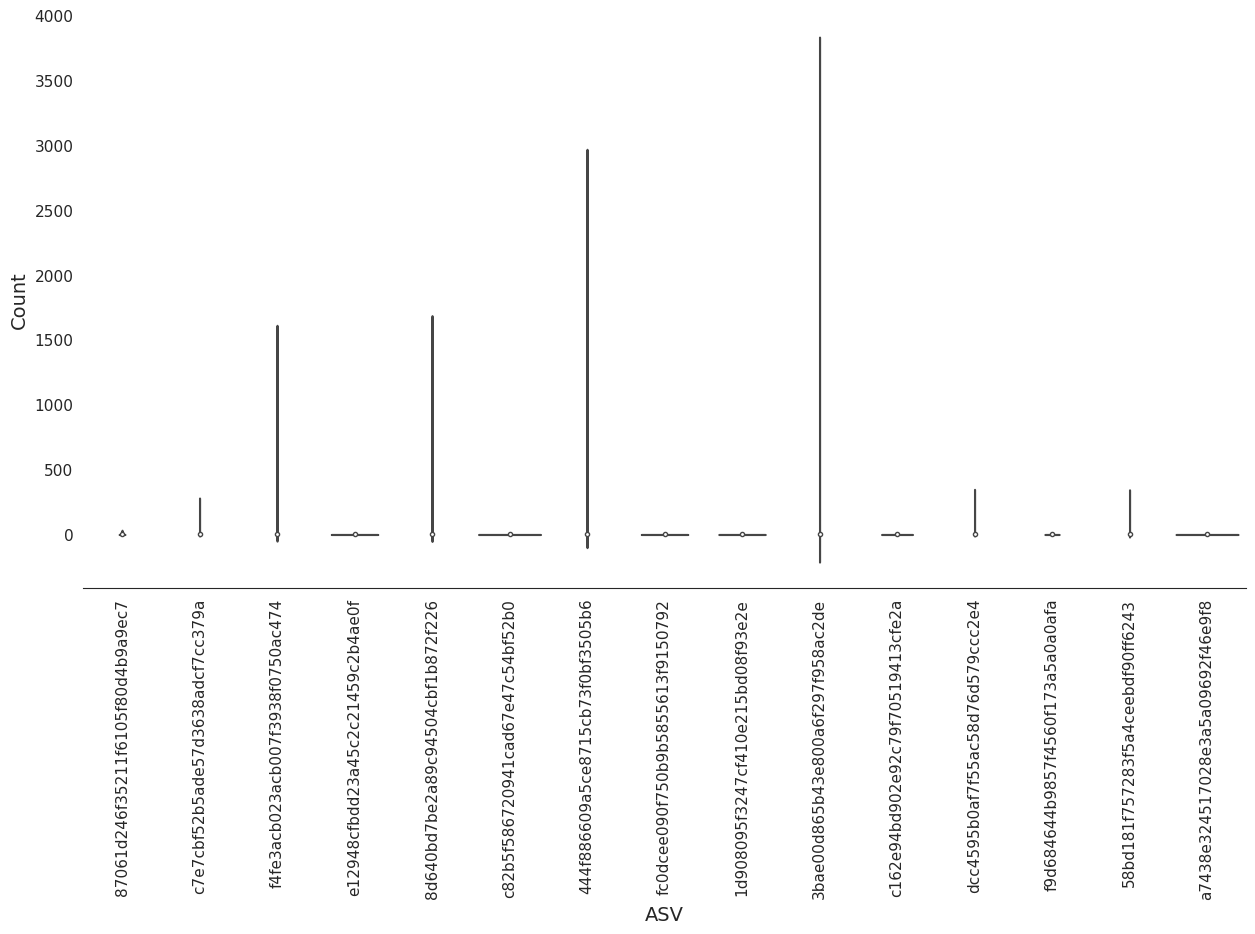

In [8]:
with sns.axes_style('white'), sns.color_palette('Set1'):
    fig, ax = plt.subplots()
    fig.set_size_inches(15, 7.5)
    
    sns.violinplot(data=data_plot, x='asv', y='count', ax=ax)
    sns.despine(left=True)
    
    # adjust tick labels and axes titles
    ax.tick_params(axis='x', rotation=90, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.set_xlabel('ASV', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)

In [9]:
#statistically testing for normality 
alpha = 0.05
results = {}

# iterate through rows (samples) and test each of them for normality
for asv_name, asv_values in data.items():
    stat, p = shapiro(asv_values)
    results[asv_name] = p

# convert test results into a DataFrame
results_df = pd.DataFrame(data=results.values(), index=results.keys(), columns=['p'])

# add a new column with a descriptive test result
results_df['is_normal'] = results_df['p'] > alpha

In [10]:
results_df

,p,is_normal
35ffcc3b809d667286737d79670b8de5,5.141034e-33,False
d46e2205f0c6ecf67b51f83d111c509c,1.878576e-32,False
2c982937754e6321f861027032db80f7,3.512602e-33,False
99deb3c5ecb022ec05609ebd1112a557,3.600188e-32,False
fd44d4cb468fd7dc9b3227867714ed87,4.138422e-34,False
...,...,...
f995b00628c62422bfba901c52048e10,7.024117e-39,False
ef500a1b2cafbc7ea19d914cc368cba0,7.024117e-39,False
6871fd2ae0f5548e5b16e9cdd0f767ac,7.024117e-39,False
919f2dcd2712ba221a695b4a98c5651c,7.024117e-39,False


In [11]:
print('Number of ASVs with normal distribution:', results_df['is_normal'].sum())

Number of ASVs with normal distribution: 0


# 2. ANCOM-BC
The first method that we use is ANCOM-BC, Analysis of Compositions of Microbiomes with Bias Correction, which is a rather conservative method when compared to other methods for differential abundance analysis. So it will set a good base for our consenus set [Nearing et al. (2022)]. ANCOM-BC estimates the unknown sampling fractions and corrects the bias induced by their differences among samples. ANCOM uses relative abundances to infer about absolute abundances. One of the deficiencies of ANCOM is that it does not provide p value for individual taxon, nor can it provide standard errors or confidence intervals of DA for each taxon, and it can be computationally intensive [Lin et al. (2020)].


## 2.1 Diet Milk

In [24]:
# create folder for diet
!mkdir -p "$daa_data_dir/ANCOM/diet"

In [25]:
! qiime feature-table filter-samples \
    --i-table $daa_data_dir/table_abund_l6.qza \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --p-where "[diet_milk]='bd' or [diet_milk]='fd'" \
    --o-filtered-table $daa_data_dir/ANCOM/diet/table_abund_diet.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/ANCOM/diet/table_abund_diet.qza


In [26]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $daa_data_dir/ANCOM/diet/table_abund_diet.qza \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --p-formula diet_milk \
    --o-differentials $daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/diet/ancombc_diet_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/diet/ancombc_diet_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/differential_abundance/ANCOM/diet/ancombc_diet_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/differential_abundance/ANCOM/diet/ancombc_diet_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an AP

In [27]:
Visualization.load(f"{daa_data_dir}/ANCOM/diet/ancombc_diet_da_barplot.qzv")

<visualization: Visualization uuid: ae8e25f6-388b-4514-9a44-e86d5c6c1bde>

In [28]:
Visualization.load(f"{daa_data_dir}/ANCOM/diet/ancombc_diet_results.qzv")

<visualization: Visualization uuid: 2c36f0a7-6bb0-4ae5-a6ab-00e3e97684b6>

## 2.2 Age (months)

In [33]:
# create folder for age
!mkdir -p "$daa_data_dir/ANCOM/age"

In [34]:
meta = pd.read_csv(f"{meta_data_dir}/metadata_merged.tsv", sep="\t")

# Add a prefix so values cannot be parsed as numbers
meta["age_group"] = meta["age_months"].astype(str).str.replace('.0', '', regex=False)
meta["age_group"] = "m" + meta["age_group"]   # m4, m7, m10

meta.to_csv(f"{daa_data_dir}/metadata_age_str.tsv", sep="\t", index=False)


In [35]:
! qiime feature-table filter-samples \
    --i-table $daa_data_dir/table_abund_l6.qza \
    --m-metadata-file $daa_data_dir/metadata_age_str.tsv \
    --p-where "[age_group]='m4' OR [age_group]='m10'" \
    --o-filtered-table $daa_data_dir/ANCOM/age/table_abund_age.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/ANCOM/age/table_abund_age.qza


In [36]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $daa_data_dir/ANCOM/age/table_abund_age.qza \
    --m-metadata-file $daa_data_dir/metadata_age_str.tsv \
    --p-formula age_group \
    --p-reference-levels age_group::m4 \
    --o-differentials $daa_data_dir/ANCOM/age/ancombc_age_differentials.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/differential_abundance/ANCOM/age/ancombc_age_differentials.qza


In [37]:
# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $daa_data_dir/ANCOM/age/ancombc_age_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/age/ancombc_age_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $daa_data_dir/ANCOM/age/ancombc_age_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/age/ancombc_age_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/differential_abundance/ANCOM/age/ancombc_age_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/differential_abundance/ANCOM/age/ancombc_age_results.qzv


In [38]:
Visualization.load(f"{daa_data_dir}/ANCOM/age/ancombc_age_da_barplot.qzv")

<visualization: Visualization uuid: 317718d5-9a0a-482b-b051-610ce94d04bc>

In [15]:
Visualization.load(f"{daa_data_dir}/ANCOM/age/ancombc_age_results.qzv")

<visualization: Visualization uuid: 3c649f76-3c03-428e-97be-fb0e4183fcb2>

## 2.3 Treatment exposure

In [44]:
# create folder for age
!mkdir -p "$daa_data_dir/ANCOM/treatment"

In [45]:
# treatment exposure has boolean values in meta data, so it needs to be changed to a string for this analysis
meta = pd.read_csv(f"{meta_data_dir}/metadata_merged.tsv", sep="\t")

# Convert booleans to strings
meta["treatment_exposure_str"] = meta["treatment_exposure"].astype(str)

# Add a prefix 
meta["treatment_exposure_str"] = "t_" + meta["treatment_exposure_str"]   # t_True, t_False

# Save back
meta.to_csv(f"{daa_data_dir}/metadata_treatment_str.tsv", sep="\t", index=False)

In [46]:
! qiime feature-table filter-samples \
    --i-table $daa_data_dir/table_abund_l6.qza \
    --m-metadata-file $daa_data_dir/metadata_treatment_str.tsv \
    --p-where "[treatment_exposure_str]='t_True' or [treatment_exposure_str]='t_False'" \
    --o-filtered-table $daa_data_dir/ANCOM/treatment/table_abund_treatment.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/ANCOM/treatment/table_abund_treatment.qza


In [47]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $daa_data_dir/ANCOM/treatment/table_abund_treatment.qza \
    --m-metadata-file $daa_data_dir/metadata_treatment_str.tsv \
    --p-formula treatment_exposure_str \
    --o-differentials $daa_data_dir/ANCOM/treatment/ancombc_treatment_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $daa_data_dir/ANCOM/treatment/ancombc_treatment_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/treatment/ancombc_treatment_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $daa_data_dir/ANCOM/treatment/ancombc_treatment_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/treatment/ancombc_treatment_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/differential_abundance/ANCOM/treatment/ancombc_treatment_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/differential_abundance/ANCOM/treatment/ancombc_treatment_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is

In [48]:
Visualization.load(f"{daa_data_dir}/ANCOM/treatment/ancombc_treatment_da_barplot.qzv")

<visualization: Visualization uuid: 64c3a925-7cf4-437b-9d83-4725e5143e3e>

In [49]:
Visualization.load(f"{daa_data_dir}/ANCOM/treatment/ancombc_treatment_results.qzv")

<visualization: Visualization uuid: ed70427a-073c-4198-93f5-0a86d8418d8c>

## 2.4 Volcano Plots
We will now create Volcano Plots for all ANCOM results.

In [ ]:
! qiime tools export \
      --input-path $daa_data_dir/ANCOM/age/ancombc_age_differentials.qza \
      --output-path $daa_data_dir/ANCOM/age/ancombc_export_age

In [ ]:
! qiime tools export \
      --input-path $daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza \
      --output-path $daa_data_dir/ANCOM/diet/ancombc_export_diet

In [ ]:
! qiime tools export \
      --input-path $daa_data_dir/ANCOM/treatment/ancombc_treatment_differentials.qza \
      --output-path $daa_data_dir/ANCOM/treatment/ancombc_export_treatment

In [4]:
#This function is used to create one results table for each metadata category.
def load_ancombc_results(daa_data_dir, variable, effect):
    """
    Loads ANCOM-BC exported differential abundance for a given variable 
    (age, diet, treatment) and merges all slices into a single DataFrame.
    
    Parameters
    ----------
    daa_data_dir: str
    variable : str
        Name of the variable folder, e.g. "age", "diet", "treatment".
    effect : str
        Column name representing the effect term in the ANCOM tables.

    Returns
    -------
    pandas.DataFrame
        Clean merged dataframe 
    """

    path = f"{daa_data_dir}/ANCOM/{variable}/ancombc_export_{variable}/"

    # Load slices
    lfc  = pd.read_csv(path + "lfc_slice.csv")
    pval = pd.read_csv(path + "p_val_slice.csv")
    qval = pd.read_csv(path + "q_val_slice.csv")
    se   = pd.read_csv(path + "se_slice.csv")
    w    = pd.read_csv(path + "w_slice.csv")

    # Merge into one table
    df = (
        lfc[["id", effect]].rename(columns={effect: "lfc"})
        .merge(pval[["id", effect]].rename(columns={effect: "p_val"}), on="id")
        .merge(qval[["id", effect]].rename(columns={effect: "q_val"}), on="id")
        .merge(se[["id", effect]].rename(columns={effect: "se"}), on="id")
        .merge(w[["id", effect]].rename(columns={effect: "w"}), on="id")
    )

    # Remove missing q-values
    df = df.dropna(subset=["q_val", "lfc"])

    # Add -log10(q)
    df["minus_log10_q"] = -np.log10(df["q_val"] + 1e-300)

    return df


In [5]:
#This function is used to create and display the volcano plots
def volcano_plot_ancombc(df, effect_label, alpha=0.05, lfc_thresh=1):
    """
    Creates a volcano plot for ANCOM-BC results.

    Parameters
    ----------
    df : pandas.DataFrame
        Table from load_ancombc_results()
    effect_label : str
        Title label to display
    alpha : float
        Significance cutoff for q-values.
    lfc_thresh : float
        Threshold for |log fold change|
    """

    df = df.copy()
    df["-log10_q"] = -np.log10(df["q_val"] + 1e-300)

    # Categorize points
    df["sig"] = "Not significant"
    df.loc[(df["q_val"] < alpha) & (df["lfc"] >= lfc_thresh), "sig"] = "Up"
    df.loc[(df["q_val"] < alpha) & (df["lfc"] <= -lfc_thresh), "sig"] = "Down"

    colors = {
        "Up": "red",
        "Down": "blue",
        "Not significant": "grey"
    }

    plt.figure(figsize=(8,6), dpi=120)

    for cat, color in colors.items():
        subset = df[df["sig"] == cat]
        plt.scatter(
            subset["lfc"],
            subset["-log10_q"],
            s=25,
            label=cat,
            c=color,
            alpha=0.7
        )

    # Threshold lines
    plt.axvline(x=lfc_thresh, color="black", linestyle="--", linewidth=1)
    plt.axvline(x=-lfc_thresh, color="black", linestyle="--", linewidth=1)
    plt.axhline(y=-np.log10(alpha), color="black", linestyle="--", linewidth=1)

    plt.xlabel("ANCOM-BC log Fold Change")
    plt.ylabel("-log10(q-value)")
    plt.title(f"Volcano Plot (ANCOM-BC) – {effect_label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

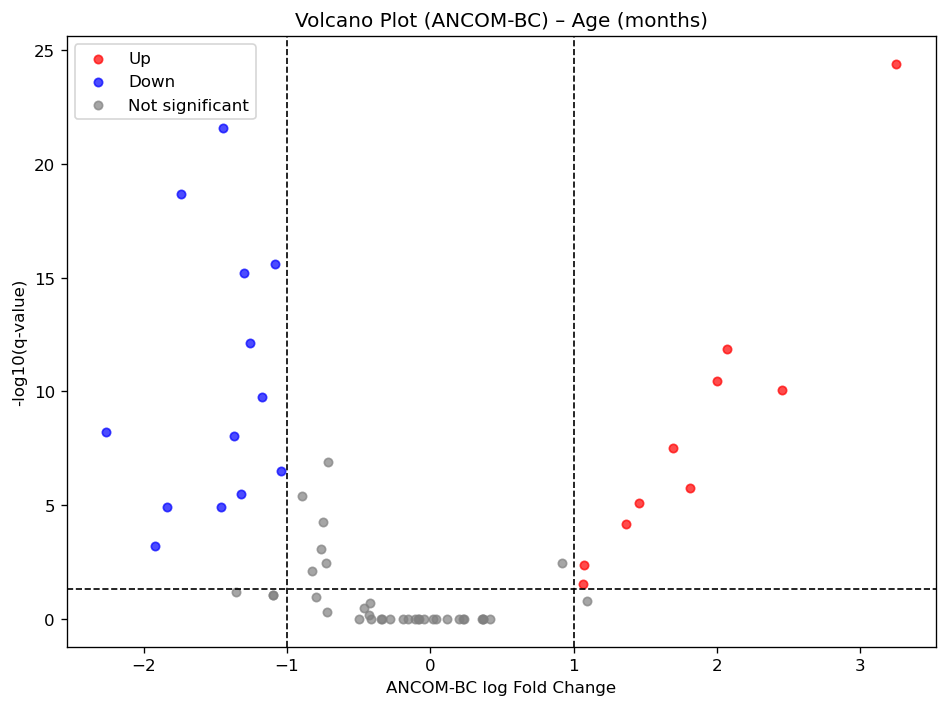

In [11]:
#age
variable = "age"               
effect = "age_groupm10"        
label = "Age (months)"         

df_ancom_age = load_ancombc_results(daa_data_dir, variable, effect)
volcano_plot_ancombc(df_ancom_age, label)

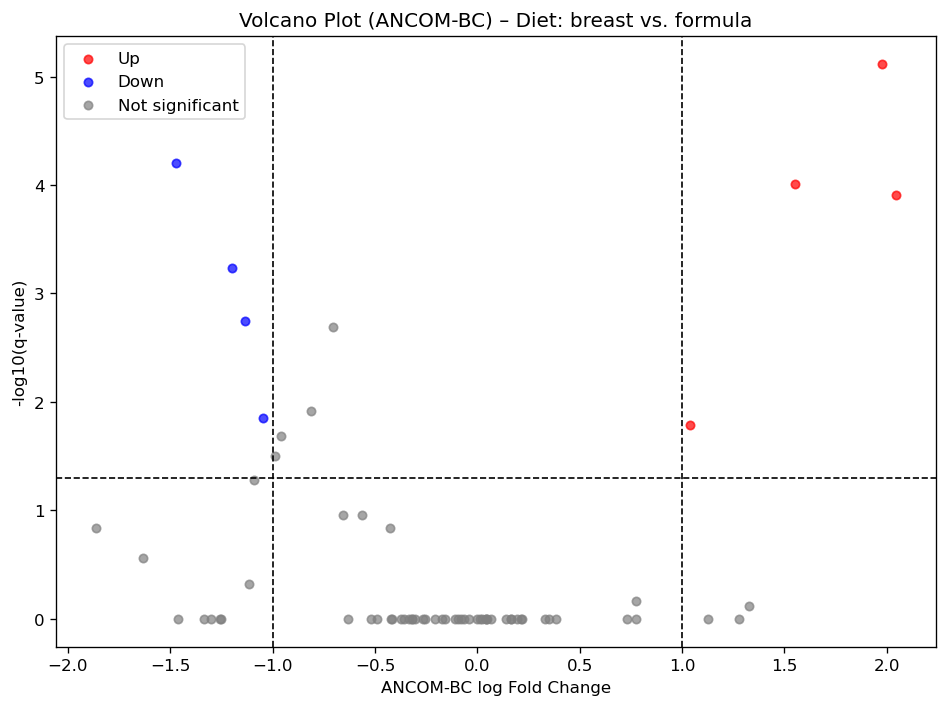

In [12]:
#diet
variable = "diet"
effect = "diet_milkfd"
label = "Diet: breast vs. formula"

df_ancom_diet = load_ancombc_results(daa_data_dir, variable, effect)
volcano_plot_ancombc(df_ancom_diet, label)

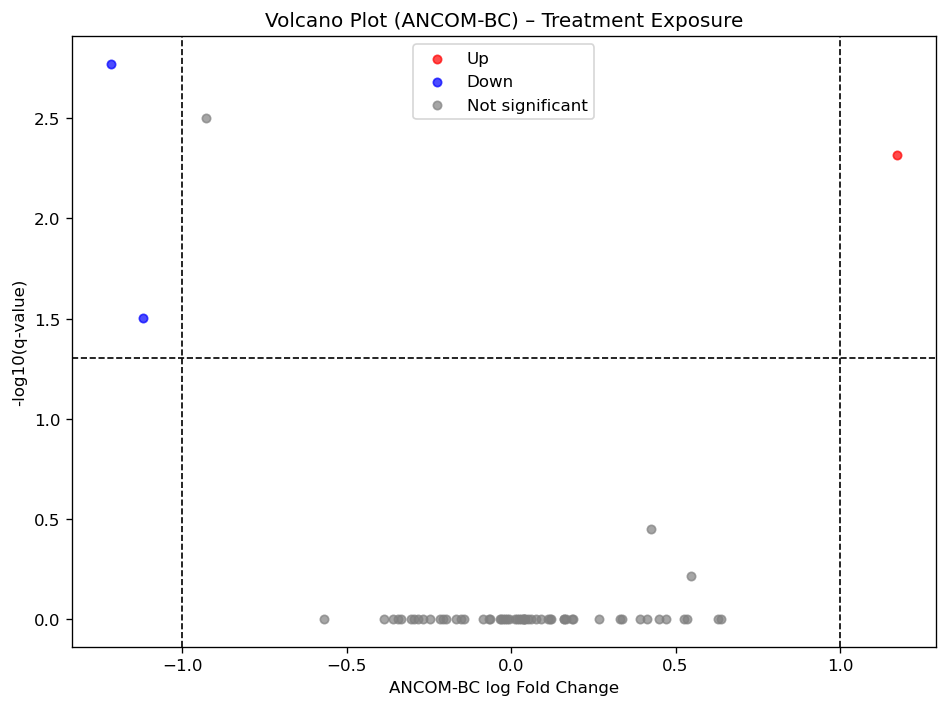

In [13]:
#treatment exposure
variable = "treatment"
effect = "treatment_exposure_strt_True" 
label = "Treatment Exposure"

df_ancom_treatment = load_ancombc_results(daa_data_dir, variable, effect)
volcano_plot_ancombc(df_ancom_treatment, label)

# 3. MaAsLin2

The second method we use is MaAsLin2. It has shown to be identify more differentially abundant taxa than ANCOM, but also to be consistent across different datasets. MaAsLin2 finds associations between microbiome multi-omics features and complex metadata in population-scale epidemiological studies. The software includes multiple analysis methods (including support for multiple covariates and repeated measures), filtering, normalization, and transform options [https://github.com/biobakery/Maaslin2].

In [54]:
! qiime tools export \
    --input-path $daa_data_dir/table_abund_l6.qza \
    --output-path $daa_data_dir/table_abund_l6_export

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/differential_abundance/table_abund_l6.qza as BIOMV210DirFmt to directory ../data/processed/differential_abundance/table_abund_l6_export


In [55]:
! biom convert \
    -i $daa_data_dir/table_abund_l6_export/feature-table.biom \
    -o $daa_data_dir/table_abund_l6_export/feature-table.tsv \
    --to-tsv

In [12]:
# enable R in Jupyter Notebook
%load_ext rpy2.ipython

The following cell needs to be run every time and takes about 20 minutes. Hint: you might want to clear the output of the cell to avoid a lot of scrolling.

In [ ]:
%%R
install.packages("remotes")
remotes::install_github("biobakery/Maaslin2")

## 3.1 Age

In [ ]:
%%R
library(Maaslin2)

#age
fit <- Maaslin2(
    input_data = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/table_abund_l6_export/feature-table.tsv",
    input_metadata = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/metadata_age_str.tsv",
    output = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/maaslin2_age",
    normalization = "TSS",
    transform = "LOG",
    analysis_method = "LM",
    fixed_effects = c("age_group"),
    reference = c("age_group,m4"),
    random_effects = c("host_id"),
)

## 3.2 Diet

In [ ]:
%%R
library(Maaslin2)

#diet
fit <- Maaslin2(
    input_data = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/table_abund_l6_export/feature-table.tsv",
    input_metadata = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/metadata/metadata_merged.tsv",
    output = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/maaslin2_diet",
    normalization = "TSS",
    transform = "LOG",
    analysis_method = "LM",
    fixed_effects = c("diet_milk"),
    reference = c("diet_milk,bd"),
    random_effects = c("host_id"),
)

## 3.3 Treatment Exposure

In [ ]:
%%R
library(Maaslin2)

#treatment exposure
fit <- Maaslin2(
    input_data = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/table_abund_l6_export/feature-table.tsv",
    input_metadata = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/metadata/metadata_merged.tsv",
    output = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/maaslin2_treatment",
    normalization = "TSS",
    transform = "LOG",
    analysis_method = "LM",
    fixed_effects = c("treatment_exposure"),
    random_effects = c("host_id"),
)

## 3.4 Volcano Plots
The following cell is used to create and display the volcano plots from the MaAsLin2 results.

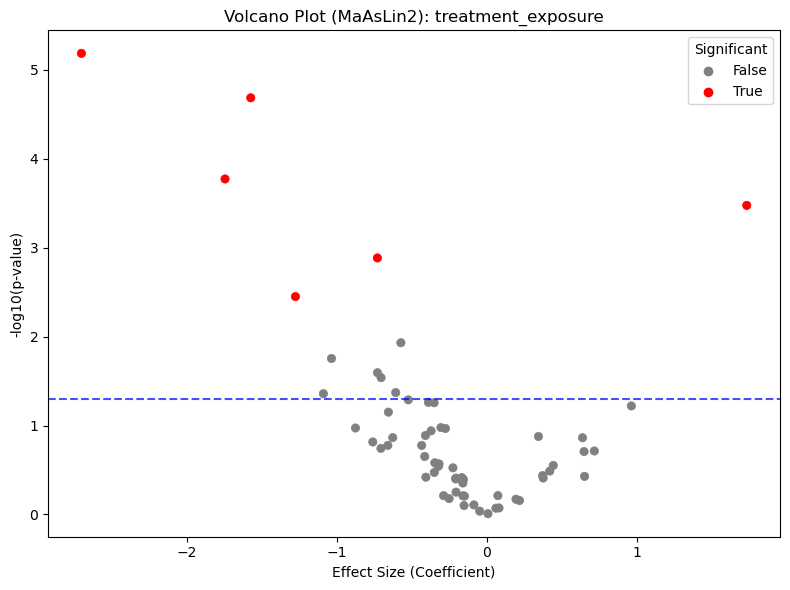

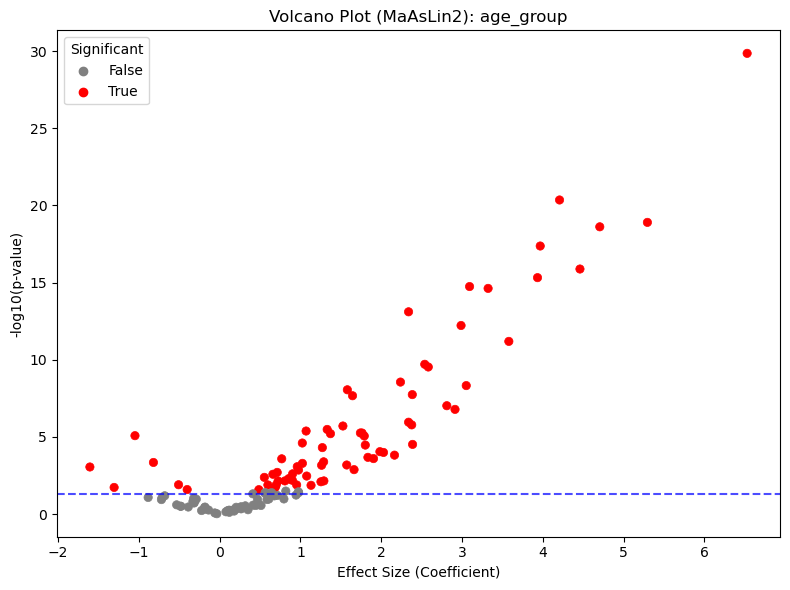

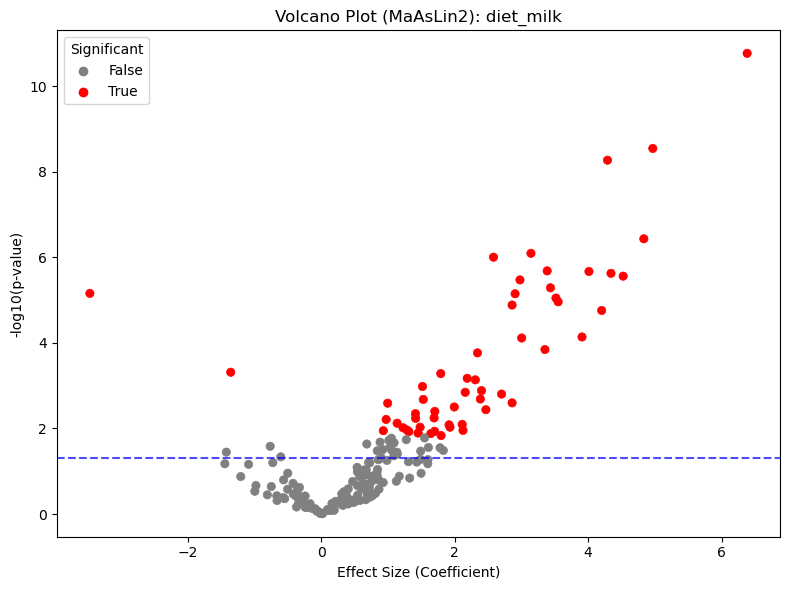

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Map metadata variables to their output folder names
maaslin_paths = {
    "age_months": f"{daa_data_dir}/maaslin2_age/all_results.tsv",
    "diet_milk": f"{daa_data_dir}/maaslin2_diet/all_results.tsv",
    "treatment_exposure": f"{daa_data_dir}/maaslin2_treatment/all_results.tsv",
}

# Volcano plot function
def volcano_plot(result_path, metadata_var, qval_threshold=0.05, top_n=10):

    # Load the correct results file
    df = pd.read_csv(result_path, sep="\t")
    
    # Filter for the metadata variable
    df_meta = df[df['metadata'] == metadata_var].copy()
    if df_meta.empty:
        print(f"No results found for {metadata_var} in {result_path}")
        return
    
    # Calculate -log10 p-value
    df_meta['neg_log10_pval'] = -np.log10(df_meta['pval'])
    
    # Define significance
    df_meta['significant'] = df_meta['qval'] < qval_threshold
    
    # Plot
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=df_meta,
        x='coef',
        y='neg_log10_pval',
        hue='significant',
        palette={True: 'red', False: 'grey'},
        edgecolor=None
    )
    
    # Horizontal line for q-value threshold
    plt.axhline(-np.log10(qval_threshold), linestyle='--', color='black', alpha=0.7)
    
    plt.xlabel('Effect Size (Coefficient)')
    plt.ylabel('-log10(p-value)')
    plt.title(f'Volcano Plot (MaAsLin2): {metadata_var}')
    plt.legend(title='Significant')
    plt.tight_layout()
    plt.show()


# === Run volcano plots for each variable ===

volcano_plot(maaslin_paths["treatment_exposure"], metadata_var="treatment_exposure")
volcano_plot(maaslin_paths["age_months"], metadata_var="age_group")
volcano_plot(maaslin_paths["diet_milk"], metadata_var="diet_milk")


# 4. DESeq2

The third method we will use is DESeq2. It provides methods to test for differential expression by use of negative binomial generalized linear models; the estimates of dispersion and logarithmic fold changes incorporate data-driven prior distributions [https://bioconductor.org/packages//release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html].

In [22]:
# create folder for delivery mode
!mkdir -p "$daa_data_dir/DESeq2"

In [7]:
# Load the feature table (TSV)
feature_table = pd.read_csv(f"{daa_data_dir}/table_abund_l6_export/feature-table.tsv", sep="\t", skiprows=1)
feature_table = feature_table.rename(columns={"#OTU ID": "Taxon"})

# Set taxonomy as the index
feature_table = feature_table.set_index("Taxon")

# Load metadata
meta = pd.read_csv(f"{meta_data_dir}/metadata_merged.tsv", sep="\t", index_col=0)

In [8]:
counts = feature_table  # taxonomy as rows, samples as columns

# Match metadata samples
shared = meta.index.intersection(counts.columns)

counts = counts[shared]
meta = meta.loc[shared]

print(counts.shape, meta.shape)

(179, 357) (357, 9)


In [4]:
# run R in Jupyter notebook
%load_ext rpy2.ipython

The following cell needs to be run every time and takes about 1 hour. Hint: Clear the output of the cell to avois a lot of scrolling.
Please select CRAN mirror 60 and choose to update all the packages.

In [ ]:
%%R
install.packages("BiocManager")
BiocManager::install("DESeq2")

In [16]:
%%R -i counts -i meta -i daa_data_dir

library(DESeq2)

run_deseq2 <- function(counts,
                       meta,
                       daa_data_dir,
                       design_vars,
                       block = NULL) {

  # check that variables exist
  all_vars <- design_vars
  if (!is.null(block)) {
    if (!(block %in% colnames(meta))) 
      stop("Block variable not found in metadata: ", block)
    all_vars <- c(block, design_vars)   # block first
  }

  missing_vars <- setdiff(all_vars, colnames(meta))
  if (length(missing_vars) > 0) {
    stop("These design variables are missing in metadata: ",
         paste(missing_vars, collapse = ", "))
  }

  # Dynamic formula
  design_formula <- as.formula(
    paste("~", paste(all_vars, collapse = " + "))
  )
  message("Using design formula: ", format(design_formula))

  # Filter low-abundance taxa
  keep <- rowSums(counts) > 5
  counts_filtered <- counts[keep, ]

  # Build DESeq2 object
  dds <- DESeqDataSetFromMatrix(
    countData = counts_filtered,
    colData   = meta,
    design    = design_formula
  )

  # Stabilize size factors
  dds <- estimateSizeFactors(dds, type = "poscounts")

  # Run Wald test
  dds <- DESeq(dds, test = "Wald")

  # Extract results for the *first* design variable (not the block)
  primary_var <- design_vars[1]

  # If numeric variable
  if (is.numeric(meta[[primary_var]])) {
    res <- results(dds, name = primary_var)
  } else {
    res <- results(dds)
    warning("Primary variable is a factor. Use results(dds, contrast=...) for specific comparisons.")
  }

  # Format output
  res_df <- as.data.frame(res)
  res_df$Taxon <- rownames(res_df)

  # Prepare output path
  out_dir <- file.path(daa_data_dir, "DESeq2")
  dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

  design_suffix <- paste(all_vars, collapse = "_")
  out_path <- file.path(out_dir, paste0("results_deseq2_", design_suffix, ".tsv"))

  write.table(res_df,
              file = out_path,
              sep = "\t",
              quote = FALSE,
              row.names = FALSE)

  message("Saved DESeq2 results to: ", out_path)

  return(list(dds = dds, res = res_df))
}

We can run the DESeq Function for age, diet, and treatment exposure.

In [17]:
%%R
#age
out_age <- run_deseq2(
  counts = counts,
  meta = meta,
  daa_data_dir = daa_data_dir,
  design_vars = "age_months",
  block = "host_id"
)

R[write to console]: Using design formula: ~host_id + age_months

R[write to console]: converting counts to integer mode

R[write to console]:   the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

R[write to console]:   the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

R[write to console]: using pre-existing size factors

R[write to console]: estimating dispersions

R[write to console]: gene-wise dispersion estimates

R[write to console]: mean-dispersion relationship

R[write to console]:

In [19]:
%%R
#diet
#drop samples that don't contain data for diet_milk
meta_clean <- meta[!is.na(meta$diet_milk), ]
counts_clean <- counts[, rownames(meta_clean)]

out_diet <- run_deseq2(
  counts = counts_clean,
  meta = meta_clean,
  daa_data_dir = daa_data_dir,
  design_vars = "diet_milk",
  block = "host_id"
)

R[write to console]: Using design formula: ~host_id + diet_milk

R[write to console]: converting counts to integer mode

R[write to console]: using pre-existing size factors

R[write to console]: estimating dispersions

R[write to console]: gene-wise dispersion estimates

R[write to console]: mean-dispersion relationship

R[write to console]: -- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

R[write to console]: final dispersion estimates

R[write to console]: fitting model and testing

R[write to console]: 42 rows did not converge in beta, labelled in mcols(object)$betaConv. Use larger maxit argument with nbinomWaldTest

R[write to console]: Saved DESeq2 results to: ../data/processed/differential_abundance/DESeq2/results_deseq2_host_id_diet_milk.tsv



In [21]:
%%R
#treatment exposure
out_treat <- run_deseq2(
  counts = counts,
  meta = meta,
  daa_data_dir = daa_data_dir,
  design_vars = "treatment_exposure"
)

R[write to console]: Using design formula: ~treatment_exposure

R[write to console]: converting counts to integer mode

R[write to console]: using pre-existing size factors

R[write to console]: estimating dispersions

R[write to console]: gene-wise dispersion estimates

R[write to console]: mean-dispersion relationship

R[write to console]: -- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

R[write to console]: final dispersion estimates

R[write to console]: fitting model and testing

R[write to console]: -- replacing outliers and refitting for 162 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

R[write to console]: estimating dispersions

R[write to console]: fitting model and testing

R[write to console]: Saved DESeq2 results to: ../data/pro

## Volcano plots

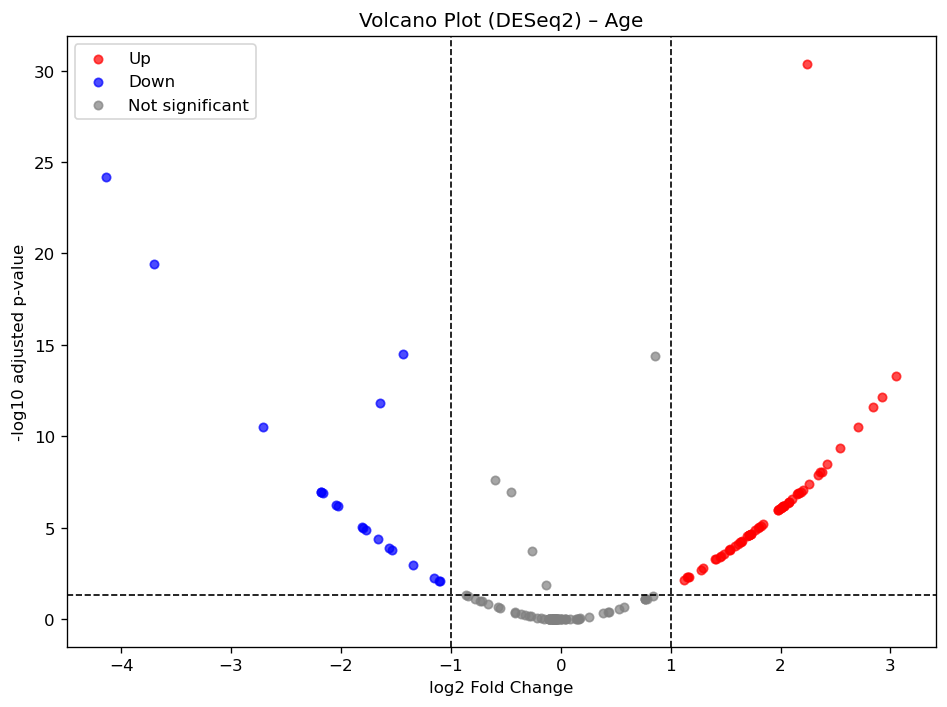

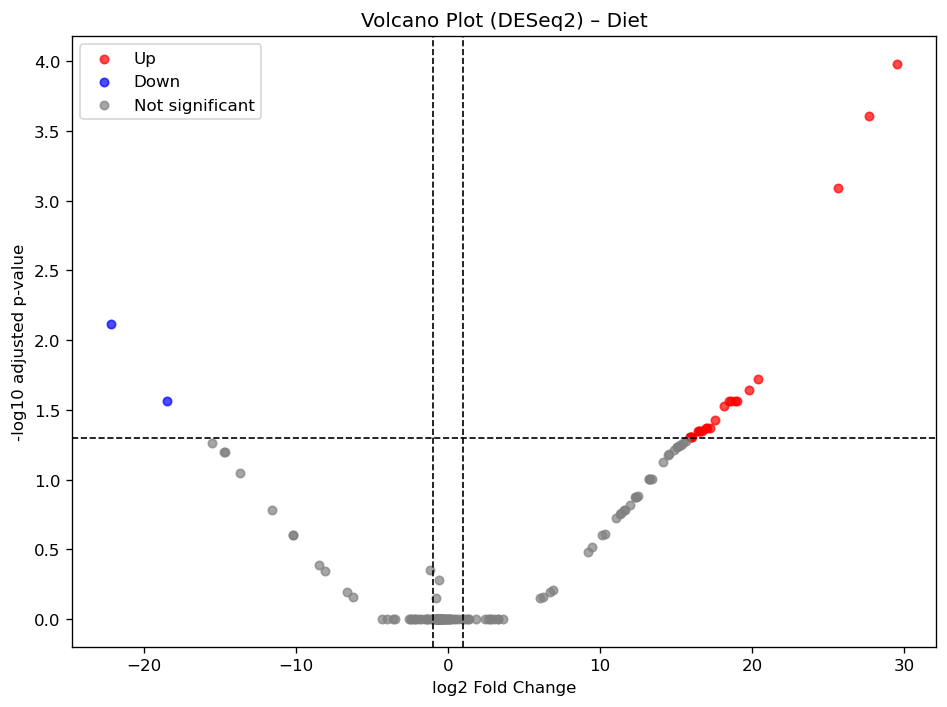

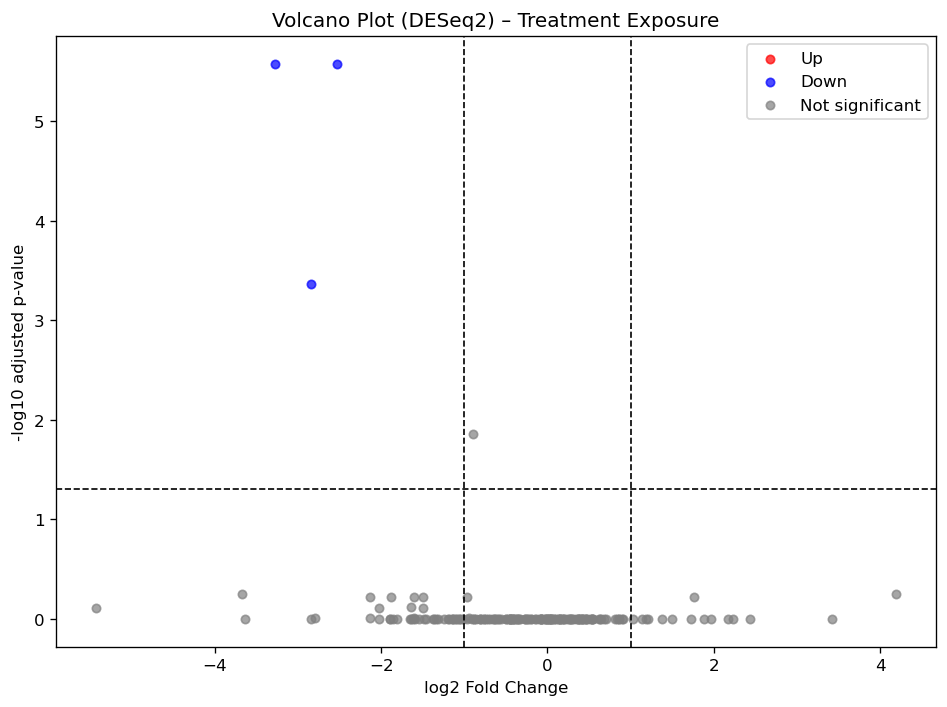

In [25]:
def plot_volcano(df_path, alpha=0.05, lfc_thresh=1, top_n=10, title=None, dpi=120):
    """
    Generate a volcano plot from a DESeq2 results file with optional top N labeling.
    
    Parameters:
    - df_path: str, path to the DESeq2 results TSV
    - alpha: float, adjusted p-value threshold for significance
    - lfc_thresh: float, log2 fold change threshold
    - top_n: int, number of top significant features to label
    - title: str, optional plot title
    - dpi: int, figure dpi
    """
    # Load data
    df = pd.read_csv(df_path, sep="\t")
    
    # Remove rows with missing padj or log2FoldChange
    df = df.dropna(subset=["padj", "log2FoldChange"])
    
    # Compute -log10(padj)
    df["-log10_padj"] = -np.log10(df["padj"])
    
    # Categorize points
    df["sig"] = "Not significant"
    df.loc[(df["padj"] < alpha) & (df["log2FoldChange"] >= lfc_thresh), "sig"] = "Up"
    df.loc[(df["padj"] < alpha) & (df["log2FoldChange"] <= -lfc_thresh), "sig"] = "Down"
    
    # Define colors
    colors = {"Up": "red", "Down": "blue", "Not significant": "grey"}
    
    # Plot points
    plt.figure(figsize=(8,6), dpi=dpi)
    for cat, color in colors.items():
        subset = df[df["sig"] == cat]
        plt.scatter(
            subset["log2FoldChange"],
            subset["-log10_padj"],
            s=25,
            label=cat,
            c=color,
            alpha=0.7
        )
    
    # Threshold lines
    plt.axvline(x=lfc_thresh, color="black", linestyle="--", linewidth=1)
    plt.axvline(x=-lfc_thresh, color="black", linestyle="--", linewidth=1)
    plt.axhline(y=-np.log10(alpha), color="black", linestyle="--", linewidth=1)
    
    """
    # Label top N significant features
    sig_df = df[df["sig"] != "Not significant"]
    if not sig_df.empty and top_n > 0:
        # Rank by -log10(padj) and absolute log2FoldChange
        sig_df["rank_score"] = sig_df["-log10_padj"] * abs(sig_df["log2FoldChange"])
        top_hits = sig_df.nlargest(top_n, "rank_score")
        for _, row in top_hits.iterrows():
            plt.text(row["log2FoldChange"], row["-log10_padj"], row["feature"],
                     fontsize=8, ha="right" if row["log2FoldChange"] < 0 else "left")
    """
    
    plt.xlabel("log2 Fold Change")
    plt.ylabel("-log10 adjusted p-value")
    if title is None:
        title = f"Volcano Plot – {df_path.split('/')[-1]}"
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_volcano(
    df_path=f"{daa_data_dir}/DESeq2/results_deseq2_host_id_age_months.tsv",
    alpha=0.05,
    lfc_thresh=1,
    top_n=10,
    title="Volcano Plot (DESeq2) – Age"
)
plot_volcano(
    df_path=f"{daa_data_dir}/DESeq2/results_deseq2_host_id_diet_milk.tsv",
    alpha=0.05,
    lfc_thresh=1,
    top_n=10,
    title="Volcano Plot (DESeq2) – Diet"
)
plot_volcano(
    df_path=f"{daa_data_dir}/DESeq2/results_deseq2_treatment_exposure.tsv",
    alpha=0.05,
    lfc_thresh=1,
    top_n=10,
    title="Volcano Plot (DESeq2) – Treatment Exposure"
)

# 5. Consensus set

We created a consensus set from the results obtained above. 

What we have in the results files:
* DESeq2: already contains a Taxon column but no explicit feature ID
* Maaslin2: uses a feature column with hashed IDs
* ANCOM-BC: uses Feature ID column, again hashed IDs
* taxonomy.tsv: maps feature IDs → taxonomy strings

What we need:
* Uniform feature ID column across methods
* Add taxonomy annotations for each feature
* Merge all methods into a single consensus table

In [9]:
# create folder for consensus results
!mkdir -p "$daa_data_dir/consensus"

## 5.1 Age

In [16]:
# adjusting the results dataframes so they all contain the same information and the colums have the same names
res_ancom_age = df_ancom_age
res_maaslin_age = pd.read_csv(f"{daa_data_dir}/maaslin2_age/all_results.tsv", sep="\t")
res_deseq_age = pd.read_csv(f"{daa_data_dir}/DESeq2/results_deseq2_host_id_age_months.tsv", sep="\t")

In [17]:
res_ancom_age.to_csv(f"{daa_data_dir}/consensus/res_ancom_age.tsv", sep="\t", index=False)
res_maaslin_age.to_csv(f"{daa_data_dir}/consensus/res_maaslin_age.tsv", sep="\t", index=False)
res_deseq_age.to_csv(f"{daa_data_dir}/consensus/res_deseq_age.tsv", sep="\t", index=False)

In [18]:
res_ancom_age.head()

,id,lfc,p_val,q_val,se,w,minus_log10_q
0,d__Bacteria;p__Actinomycetota;c__Actinobacteri...,-0.346894,0.283037,1.000000,0.323136,-1.073523,-0.000000
1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,-1.358978,0.002264,0.067931,0.445103,-3.053173,1.167934
2,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,-0.089563,0.852406,1.000000,0.481391,-0.186050,-0.000000
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,1.090714,0.006269,0.163000,0.399038,2.733358,0.787813
4,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...,-1.096762,0.003028,0.087078,0.369918,-2.964880,1.060092


In [19]:
res_maaslin_age.head()

,feature,metadata,value,coef,stderr,N,N.not.0,pval,qval
0,d__Bacteria.p__Bacillota.c__Clostridia.o__Lach...,age_group,m10,6.527891,0.496842,357,183,1.382648e-30,1.714483e-28
1,d__Bacteria.p__Bacillota.c__Clostridia.o__Lach...,age_group,m10,4.206623,0.411120,357,151,4.403611e-21,2.730239e-19
2,d__Bacteria.p__Bacillota.c__Clostridia.o__Osci...,age_group,m10,5.293830,0.542634,357,144,1.246448e-19,5.151987e-18
3,d__Bacteria.p__Bacillota.c__Clostridia.o__Lach...,age_group,m10,4.704451,0.485395,357,145,2.411551e-19,7.475810e-18
4,d__Bacteria.p__Bacillota.c__Clostridia.o__Lach...,age_group,m10,3.967625,0.427947,357,94,4.239703e-18,1.051446e-16


In [20]:
res_deseq_age = pd.read_csv(f"{daa_data_dir}/consensus/res_deseq_age.tsv", sep="\t")
res_deseq_age.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Taxon
0,11032.347777,-0.136542,0.051000,-2.677279,7.422270e-03,1.440794e-02,d__Bacteria;p__Actinomycetota;c__Actinobacteri...
1,4917.357749,-0.456781,0.080588,-5.668102,1.443881e-08,1.089025e-07,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...
2,9923.939680,-0.027129,0.067841,-0.399888,6.892394e-01,9.732344e-01,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...
3,1058.929820,1.150930,0.382461,3.009277,2.618699e-03,5.401067e-03,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...
4,1009.168738,-1.648898,0.220613,-7.474152,7.770313e-14,1.602627e-12,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...


Since the MaAsLin2 results don't contain a taxon column we will add it to the results table. And we will make the taxon the feature id in all the results tables so that we can merged them based on these feature ids.

In [30]:
# Clean DeSEQ2
deseq = res_deseq_age.rename(columns={"Taxon": "feature_id"})
deseq["feature_id"] = deseq["feature_id"].astype(str)

# Keep only clean output columns
deseq_clean_age = deseq[[
    "feature_id", "log2FoldChange", "lfcSE", "pvalue", "padj"
]]

# Save file
deseq_clean_age.to_csv(f"{daa_data_dir}/consensus/clean_deseq2_age.tsv", sep="\t", index=False)


# Clean MaAsLin2
maaslin = res_maaslin_age.rename(columns={"feature": "feature_id"})

# Keep only clean output columns
maaslin_clean_age = maaslin[[
    "feature_id", "coef", "stderr", "pval", "qval"
]]

# Save cleaned file
maaslin_clean_age.to_csv(f"{daa_data_dir}/consensus/clean_maaslin2_age.tsv", sep="\t", index=False)


# Clean ANCOM-BC
ancom = res_ancom_age.rename(columns={"id": "feature_id"})
ancom["feature_id"] = ancom["feature_id"].astype(str)

# Keep only clean output colums
ancom_clean_age = ancom[[
    "feature_id", "lfc", "se", "p_val", "q_val", "minus_log10_q"
]]

# Save file
ancom_clean_age.to_csv(f"{daa_data_dir}/consensus/clean_ancombc_age.tsv", sep="\t", index=False)

In [31]:
ancom_clean_age.head()

,feature_id,lfc,se,p_val,q_val,minus_log10_q
0,d__Bacteria;p__Actinomycetota;c__Actinobacteri...,-0.346894,0.323136,0.283037,1.000000,-0.000000
1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,-1.358978,0.445103,0.002264,0.067931,1.167934
2,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,-0.089563,0.481391,0.852406,1.000000,-0.000000
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,1.090714,0.399038,0.006269,0.163000,0.787813
4,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...,-1.096762,0.369918,0.003028,0.087078,1.060092


In [32]:
maaslin_clean_age.head()

,feature_id,coef,stderr,pval,qval
0,d__Bacteria.p__Bacillota.c__Clostridia.o__Lach...,6.527891,0.496842,1.382648e-30,1.714483e-28
1,d__Bacteria.p__Bacillota.c__Clostridia.o__Lach...,4.206623,0.411120,4.403611e-21,2.730239e-19
2,d__Bacteria.p__Bacillota.c__Clostridia.o__Osci...,5.293830,0.542634,1.246448e-19,5.151987e-18
3,d__Bacteria.p__Bacillota.c__Clostridia.o__Lach...,4.704451,0.485395,2.411551e-19,7.475810e-18
4,d__Bacteria.p__Bacillota.c__Clostridia.o__Lach...,3.967625,0.427947,4.239703e-18,1.051446e-16


In [27]:
deseq_clean_age.head()

,feature_id,log2FoldChange,lfcSE,pvalue,padj
0,d__Bacteria;p__Actinomycetota;c__Actinobacteri...,-0.136542,0.051000,7.422270e-03,1.440794e-02
1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,-0.456781,0.080588,1.443881e-08,1.089025e-07
2,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,-0.027129,0.067841,6.892394e-01,9.732344e-01
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,1.150930,0.382461,2.618699e-03,5.401067e-03
4,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...,-1.648898,0.220613,7.770313e-14,1.602627e-12


Now that we have all the cleaned up dataframes, we can continue with building the consensus set. 

In [33]:
# Significance flags
deseq_sig_age = deseq_clean_age.assign(
    deseq_sig_age = deseq_clean_age["padj"] < 0.05
)

maaslin_sig_age = maaslin_clean_age.assign(
    maaslin_sig_age = maaslin_clean_age["qval"] < 0.05
)

ancom_sig_age = ancom_clean_age.assign(
    ancom_sig_age = ancom_clean_age["q_val"] < 0.05
)


# Rename columns for merging clarity
deseq_sig_age = deseq_sig_age.rename(columns={
    "log2FoldChange": "deseq_lfc",
    "pvalue": "deseq_p",
    "padj": "deseq_q"
})

maaslin_sig_age = maaslin_sig_age.rename(columns={
    "coef": "maaslin_lfc",
    "pval": "maaslin_p",
    "qval": "maaslin_q"
})

ancom_sig_age = ancom_sig_age.rename(columns={
    "lfc": "ancom_lfc",
    "p_val": "ancom_p",
    "q_val": "ancom_q"
})


# Merge all results on feature_id
consensus_age = (
    deseq_sig_age
    .merge(maaslin_sig_age, on="feature_id", how="outer")
    .merge(ancom_sig_age, on="feature_id", how="outer")
)

In [34]:
# Count how many methods call a feature significant
consensus_age["n_significant"] = (
    consensus_age[["deseq_sig_age", "maaslin_sig_age", "ancom_sig_age"]]
    .sum(axis=1, skipna=True)
)


# Determine consensus direction -> majority vote among LFC signs
def consensus_direction(row):
    signs = []

    for col in ["deseq_lfc", "maaslin_lfc", "ancom_lfc"]:
        val = row[col]
        if pd.notnull(val):
            if val > 0:
                signs.append(1)
            elif val < 0:
                signs.append(-1)

    if len(signs) == 0:
        return None
    
    total = sum(signs)
    if total > 0:
        return "up"
    elif total < 0:
        return "down"
    else:
        return "mixed"

consensus_age["direction"] = consensus_age.apply(consensus_direction, axis=1)

In [35]:
consensus_age.to_csv(f"{daa_data_dir}/consensus/consensus_age.tsv", sep="\t", index=False)

In [36]:
consensus_age.head(20)

,feature_id,deseq_lfc,lfcSE,deseq_p,deseq_q,deseq_sig_age,maaslin_lfc,stderr,maaslin_p,maaslin_q,maaslin_sig_age,ancom_lfc,se,ancom_p,ancom_q,minus_log10_q,ancom_sig_age,n_significant,direction
0,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,0.553901,0.191933,4.184206e-03,9.433483e-03,True,NaN,NaN,NaN,NaN,NaN,NaN,1,up
1,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,0.099580,0.191848,6.041022e-01,6.294846e-01,False,NaN,NaN,NaN,NaN,NaN,NaN,0,up
2,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,0.512919,0.471709,2.778111e-01,3.444858e-01,False,NaN,NaN,NaN,NaN,NaN,NaN,0,up
3,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,-0.482585,0.471523,3.069750e-01,3.731853e-01,False,NaN,NaN,NaN,NaN,NaN,NaN,0,down
4,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,0.953431,0.380758,1.291022e-02,2.455736e-02,True,NaN,NaN,NaN,NaN,NaN,NaN,1,up
5,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,0.819155,0.380582,3.231465e-02,5.489064e-02,False,NaN,NaN,NaN,NaN,NaN,NaN,0,up
6,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,-0.316360,0.241677,1.916029e-01,2.500922e-01,False,NaN,NaN,NaN,NaN,NaN,NaN,0,down
7,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,-0.172373,0.241793,4.765053e-01,5.275595e-01,False,NaN,NaN,NaN,NaN,NaN,NaN,0,down
8,d__Bacteria.p__Actinomycetota.c__Coriobacterii...,NaN,NaN,NaN,NaN,NaN,-0.185939,0.214032,3.857729e-01,4.429245e-01,False,NaN,NaN,NaN,NaN,NaN,NaN,0,down
9,d__Bacteria.p__Actinomycetota.c__Coriobacterii...,NaN,NaN,NaN,NaN,NaN,0.078780,0.214132,7.132375e-01,7.309211e-01,False,NaN,NaN,NaN,NaN,NaN,NaN,0,up


In [38]:
#create final consensus set -> features are added if they were found to differentially abundant by at least 2 of the used methods
consensus_features_age = consensus_age[consensus_age["n_significant"] >= 2]

final_consensus_age = consensus_features_age[[
    "feature_id",
    "deseq_lfc", "maaslin_lfc", "ancom_lfc",
    "deseq_sig_age", "maaslin_sig_age", "ancom_sig_age",
    "n_significant",
    "direction"
]].sort_values("n_significant", ascending=False)

final_consensus_age.to_csv(f"{daa_data_dir}/consensus/final_consensus_age.tsv", sep="\t", index=False)

In [39]:
final_consensus_age

,feature_id,deseq_lfc,maaslin_lfc,ancom_lfc,deseq_sig_age,maaslin_sig_age,ancom_sig_age,n_significant,direction
144,d__Bacteria;p__Bacillota;c__Bacilli;o__Erysipe...,1.404839,NaN,1.814401,True,NaN,True,2,up
194,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,2.360500,NaN,1.695481,True,NaN,True,2,up
284,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,-0.597525,NaN,-1.918417,True,NaN,True,2,down
283,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,-1.107660,NaN,-1.320559,True,NaN,True,2,down
241,d__Bacteria;p__Bacillota;c__Clostridia;o__Pept...,0.858761,NaN,1.074660,True,NaN,True,2,up
228,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,2.840750,NaN,2.453210,True,NaN,True,2,up
217,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,1.806748,NaN,1.065242,True,NaN,True,2,up
202,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,2.922712,NaN,1.452754,True,NaN,True,2,up
181,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,2.544670,NaN,3.251708,True,NaN,True,2,up
148,d__Bacteria;p__Bacillota;c__Bacilli;o__Erysipe...,1.295994,NaN,0.920694,True,NaN,True,2,up


This table shows the 15 features that were differentially expressed in at least two of the three methods. If we have a closer look at the table we can see that all the features were found by DeSeq2 and ANCOM-BC but not by MaAsLin2. 

## 5.2 Diet (dominantly breast fed and dominantly formula fed)

In [40]:
# adjusting the results dataframes so they all contain the same information and the colums have the same names
res_ancom_diet = df_ancom_diet
res_maaslin_diet = pd.read_csv(f"{daa_data_dir}/maaslin2_diet/all_results.tsv", sep="\t")
res_deseq_diet = pd.read_csv(f"{daa_data_dir}/DESeq2/results_deseq2_host_id_diet_milk.tsv", sep="\t")

In [41]:
res_ancom_diet.to_csv(f"{daa_data_dir}/consensus/res_ancom_diet.tsv", sep="\t", index=False)
res_maaslin_diet.to_csv(f"{daa_data_dir}/consensus/res_maaslin_diet.tsv", sep="\t", index=False)
res_deseq_diet.to_csv(f"{daa_data_dir}/consensus/res_deseq_diet.tsv", sep="\t", index=False)

In [42]:
res_ancom_diet.head()

,id,lfc,p_val,q_val,se,w,minus_log10_q
0,d__Bacteria;p__Actinomycetota;c__Actinobacteri...,0.731635,0.200165,1.0,0.571108,1.281081,-0.0
1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,1.275924,0.092230,1.0,0.757787,1.683750,-0.0
2,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,-1.333422,0.082103,1.0,0.766947,-1.738610,-0.0
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,0.211221,0.728210,1.0,0.607818,0.347508,-0.0
4,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...,1.126453,0.057219,1.0,0.592361,1.901631,-0.0


In [43]:
res_maaslin_diet.head()

,feature,metadata,value,coef,stderr,N,N.not.0,pval,qval
0,d__Bacteria.p__Bacillota.c__Clostridia.o__Lach...,diet_milk,diet_milk,6.380055,0.917140,357,183,1.720652e-11,3.200412e-09
1,d__Bacteria.p__Bacillota.c__Clostridia.o__Lach...,diet_milk,diet_milk,4.966796,0.814376,357,145,2.869484e-09,2.668620e-07
2,d__Bacteria.p__Bacillota.c__Clostridia.o__Lach...,diet_milk,diet_milk,4.288367,0.716757,357,151,5.392488e-09,3.343342e-07
3,d__Bacteria.p__Bacillota.c__Clostridia.o__Osci...,diet_milk,diet_milk,4.832313,0.932435,357,144,3.705557e-07,1.723084e-05
4,d__Bacteria.p__Bacillota.c__Clostridia.o__Pept...,diet_milk,mixed,3.141990,0.624023,357,209,8.088199e-07,3.008810e-05


In [44]:
res_deseq_diet = pd.read_csv(f"{daa_data_dir}/consensus/res_deseq_diet.tsv", sep="\t")
res_deseq_diet.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Taxon
0,12192.966676,-0.621533,0.490259,-1.267766,0.204882,0.523586,d__Bacteria;p__Actinomycetota;c__Actinobacteri...
1,5937.864033,-1.150948,0.837218,-1.374730,0.169215,0.446617,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...
2,9802.975374,-0.768584,0.746095,-1.030142,0.302944,0.706868,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...
3,1173.990790,3.278684,5.912731,0.554513,0.579228,0.999954,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...
4,1115.347920,-10.173617,5.922625,-1.717755,0.085841,0.249047,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...


In [47]:
# Clean DeSEQ2
deseq = res_deseq_diet.rename(columns={"Taxon": "feature_id"})
deseq["feature_id"] = deseq["feature_id"].astype(str)

# Keep only clean output columns
deseq_clean_diet = deseq[[
    "feature_id", "log2FoldChange", "lfcSE", "pvalue", "padj"
]]

# Save file
deseq_clean_diet.to_csv(f"{daa_data_dir}/consensus/clean_deseq2_diet.tsv", sep="\t", index=False)


# Clean MaAsLin2
maaslin = res_maaslin_diet.rename(columns={"feature": "feature_id"})

# Keep only clean output columns
maaslin_clean_diet = maaslin[[
    "feature_id", "coef", "stderr", "pval", "qval"
]]

# Save cleaned file
maaslin_clean_diet.to_csv(f"{daa_data_dir}/consensus/clean_maaslin2_diet.tsv", sep="\t", index=False)


# Clean ANCOM-BC
ancom = res_ancom_diet.rename(columns={"id": "feature_id"})
ancom["feature_id"] = ancom["feature_id"].astype(str)

# Keep only clean output columns
ancom_clean_diet = ancom[[
    "feature_id", "lfc", "se", "p_val", "q_val", "minus_log10_q"
]]

# Save file
ancom_clean_diet.to_csv(f"{daa_data_dir}/consensus/clean_ancombc_diet.tsv", sep="\t", index=False)

In [48]:
ancom_clean_diet.head()

,feature_id,lfc,se,p_val,q_val,minus_log10_q
0,d__Bacteria;p__Actinomycetota;c__Actinobacteri...,0.731635,0.571108,0.200165,1.0,-0.0
1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,1.275924,0.757787,0.092230,1.0,-0.0
2,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,-1.333422,0.766947,0.082103,1.0,-0.0
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,0.211221,0.607818,0.728210,1.0,-0.0
4,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...,1.126453,0.592361,0.057219,1.0,-0.0


In [49]:
maaslin_clean_diet.head()

,feature_id,coef,stderr,pval,qval
0,d__Bacteria.p__Bacillota.c__Clostridia.o__Lach...,6.380055,0.917140,1.720652e-11,3.200412e-09
1,d__Bacteria.p__Bacillota.c__Clostridia.o__Lach...,4.966796,0.814376,2.869484e-09,2.668620e-07
2,d__Bacteria.p__Bacillota.c__Clostridia.o__Lach...,4.288367,0.716757,5.392488e-09,3.343342e-07
3,d__Bacteria.p__Bacillota.c__Clostridia.o__Osci...,4.832313,0.932435,3.705557e-07,1.723084e-05
4,d__Bacteria.p__Bacillota.c__Clostridia.o__Pept...,3.141990,0.624023,8.088199e-07,3.008810e-05


In [50]:
deseq_clean_diet.head()

,feature_id,log2FoldChange,lfcSE,pvalue,padj
0,d__Bacteria;p__Actinomycetota;c__Actinobacteri...,-0.621533,0.490259,0.204882,0.523586
1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,-1.150948,0.837218,0.169215,0.446617
2,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,-0.768584,0.746095,0.302944,0.706868
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,3.278684,5.912731,0.579228,0.999954
4,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...,-10.173617,5.922625,0.085841,0.249047


In [51]:
# Significance flags (same as for age, just here for completeness and so it can be run independantly)
deseq_sig_diet = deseq_clean_diet.assign(
    deseq_sig_diet = deseq_clean_diet["padj"] < 0.05
)

maaslin_sig_diet = maaslin_clean_diet.assign(
    maaslin_sig_diet = maaslin_clean_diet["qval"] < 0.05
)

ancom_sig_diet= ancom_clean_age.assign(
    ancom_sig_diet = ancom_clean_diet["q_val"] < 0.05
)


# Rename columns for merging clarity
deseq_sig_diet = deseq_sig_diet.rename(columns={
    "log2FoldChange": "deseq_lfc",
    "pvalue": "deseq_p",
    "padj": "deseq_q"
})

maaslin_sig_diet = maaslin_sig_diet.rename(columns={
    "coef": "maaslin_lfc",
    "pval": "maaslin_p",
    "qval": "maaslin_q"
})

ancom_sig_diet = ancom_sig_diet.rename(columns={
    "lfc": "ancom_lfc",
    "p_val": "ancom_p",
    "q_val": "ancom_q"
})


# Merge all results on feature_id
consensus_diet = (
    deseq_sig_diet
    .merge(maaslin_sig_diet, on="feature_id", how="outer")
    .merge(ancom_sig_diet, on="feature_id", how="outer")
)

In [52]:
# Count how many methods call a feature significant
consensus_diet["n_significant"] = (
    consensus_diet[["deseq_sig_diet", "maaslin_sig_diet", "ancom_sig_diet"]]
    .sum(axis=1, skipna=True)
)


# Determine consensus direction -> majority vote among LFC signs
def consensus_direction(row):
    signs = []

    for col in ["deseq_lfc", "maaslin_lfc", "ancom_lfc"]:
        val = row[col]
        if pd.notnull(val):
            if val > 0:
                signs.append(1)
            elif val < 0:
                signs.append(-1)

    if len(signs) == 0:
        return None
    
    total = sum(signs)
    if total > 0:
        return "up"
    elif total < 0:
        return "down"
    else:
        return "mixed"

consensus_diet["direction"] = consensus_diet.apply(consensus_direction, axis=1)

In [53]:
consensus_diet.to_csv(f"{daa_data_dir}/consensus/consensus_diet.tsv", sep="\t", index=False)

In [54]:
consensus_diet.head(10)

,feature_id,deseq_lfc,lfcSE,deseq_p,deseq_q,deseq_sig_diet,maaslin_lfc,stderr,maaslin_p,maaslin_q,maaslin_sig_diet,ancom_lfc,se,ancom_p,ancom_q,minus_log10_q,ancom_sig_diet,n_significant,direction
0,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,0.216717,0.322957,0.502636,0.603163,False,NaN,NaN,NaN,NaN,NaN,NaN,0,up
1,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,0.161646,0.279527,0.563465,0.642973,False,NaN,NaN,NaN,NaN,NaN,NaN,0,up
2,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,-0.088362,0.311889,0.777103,0.821257,False,NaN,NaN,NaN,NaN,NaN,NaN,0,down
3,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,1.170370,0.772315,0.130571,0.237037,False,NaN,NaN,NaN,NaN,NaN,NaN,0,up
4,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,-0.664855,0.746183,0.373534,0.492081,False,NaN,NaN,NaN,NaN,NaN,NaN,0,down
5,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,0.409253,0.672675,0.543351,0.625840,False,NaN,NaN,NaN,NaN,NaN,NaN,0,up
6,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,1.993757,0.670504,0.003146,0.016721,True,NaN,NaN,NaN,NaN,NaN,NaN,1,up
7,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,0.839211,0.554132,0.131006,0.237037,False,NaN,NaN,NaN,NaN,NaN,NaN,0,up
8,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,0.144217,0.642670,0.822576,0.845299,False,NaN,NaN,NaN,NaN,NaN,NaN,0,up
9,d__Bacteria.p__Actinomycetota.c__Actinobacteri...,NaN,NaN,NaN,NaN,NaN,-0.724109,0.388105,0.062905,0.137195,False,NaN,NaN,NaN,NaN,NaN,NaN,0,down


In [55]:
#create final consensus set -> features are added if they were found to differentially abundant by at least 2 of the used methods
consensus_features_diet = consensus_diet[consensus_diet["n_significant"] >= 2]

final_consensus_diet = consensus_features_diet[[
    "feature_id",
    "deseq_lfc", "maaslin_lfc", "ancom_lfc",
    "deseq_sig_diet", "maaslin_sig_diet", "ancom_sig_diet",
    "n_significant",
    "direction"
]].sort_values("n_significant", ascending=False)

final_consensus_diet.to_csv(f"{daa_data_dir}/consensus/final_consensus_diet.tsv", sep="\t", index=False)

In [56]:
final_consensus_diet

,feature_id,deseq_lfc,maaslin_lfc,ancom_lfc,deseq_sig_diet,maaslin_sig_diet,ancom_sig_diet,n_significant,direction
241,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,25.634024,NaN,2.068408,True,NaN,True,2,up
243,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,19.759146,NaN,3.251708,True,NaN,True,2,up
290,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,16.422457,NaN,2.453210,True,NaN,True,2,up
361,d__Bacteria;p__Thermodesulfobacteriota;c__Desu...,18.630115,NaN,-0.762727,True,NaN,True,2,mixed


## 5.3 Treatment exposure

In [78]:
# adjusting the results dataframes so they all contain the same information and the colums have the same names
res_ancom_treatment = df_ancom_treatment
res_maaslin_treatment = pd.read_csv(f"{daa_data_dir}/maaslin2_treatment/all_results.tsv", sep="\t")
res_deseq_treatment = pd.read_csv(f"{daa_data_dir}/DESeq2/results_deseq2_treatment_exposure.tsv", sep="\t")

In [79]:
res_ancom_treatment.to_csv(f"{daa_data_dir}/consensus/res_ancom_treatment.tsv", sep="\t", index=False)
res_maaslin_treatment.to_csv(f"{daa_data_dir}/consensus/res_maaslin_treatment.tsv", sep="\t", index=False)
res_deseq_treatment.to_csv(f"{daa_data_dir}/consensus/res_deseq_treatment.tsv", sep="\t", index=False)

In [80]:
res_ancom_treatment.head()

,id,lfc,p_val,q_val,se,w,minus_log10_q
0,d__Bacteria;p__Actinomycetota;c__Actinobacteri...,-0.358965,0.153169,1.000000,0.251301,-1.428427,-0.000000
1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,0.637573,0.068710,1.000000,0.350253,1.820323,-0.000000
2,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,0.450113,0.248683,1.000000,0.390197,1.153553,-0.000000
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,0.187098,0.566543,1.000000,0.326438,0.573150,-0.000000
4,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...,-1.117422,0.000536,0.031602,0.322742,-3.462274,1.500281


In [81]:
res_maaslin_treatment.head()

,feature,metadata,value,coef,stderr,N,N.not.0,pval,qval
0,d__Bacteria.p__Bacillota.c__Bacilli.o__Lactoba...,treatment_exposure,True,-2.705409,0.581802,357,142,0.000007,0.000406
1,d__Bacteria.p__Actinomycetota.c__Coriobacterii...,treatment_exposure,True,-1.575281,0.358998,357,177,0.000021,0.000642
2,d__Bacteria.p__Bacillota.c__Bacilli.o__Lactoba...,treatment_exposure,True,-1.747016,0.454166,357,134,0.000169,0.003498
3,d__Bacteria.p__Bacillota.c__Negativicutes.o__V...,treatment_exposure,True,1.734776,0.473261,357,314,0.000336,0.005202
4,d__Bacteria.p__Pseudomonadota.c__Gammaproteoba...,treatment_exposure,True,-0.730056,0.223147,357,74,0.001308,0.016214


In [82]:
res_deseq_diet = pd.read_csv(f"{daa_data_dir}/consensus/res_deseq_diet.tsv", sep="\t")
res_deseq_diet.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Taxon
0,12192.966676,-0.621533,0.490259,-1.267766,0.204882,0.523586,d__Bacteria;p__Actinomycetota;c__Actinobacteri...
1,5937.864033,-1.150948,0.837218,-1.374730,0.169215,0.446617,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...
2,9802.975374,-0.768584,0.746095,-1.030142,0.302944,0.706868,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...
3,1173.990790,3.278684,5.912731,0.554513,0.579228,0.999954,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...
4,1115.347920,-10.173617,5.922625,-1.717755,0.085841,0.249047,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...


In [83]:
# Clean DeSEQ2
deseq = res_deseq_treatment.rename(columns={"Taxon": "feature_id"})
deseq["feature_id"] = deseq["feature_id"].astype(str)

# Keep only clean output columns
deseq_clean_treatment = deseq[[
    "feature_id", "log2FoldChange", "lfcSE", "pvalue", "padj"
]]

# Save file
deseq_clean_treatment.to_csv(f"{daa_data_dir}/consensus/clean_deseq2_treatment.tsv", sep="\t", index=False)


# Clean MaAsLin2
maaslin = res_maaslin_treatment.rename(columns={"feature": "feature_id"})

# Keep only clean output columns
maaslin_clean_treatment = maaslin[[
    "feature_id", "coef", "stderr", "pval", "qval"
]]

# Save cleaned file
maaslin_clean_treatment.to_csv(f"{daa_data_dir}/consensus/clean_maaslin2_treatment.tsv", sep="\t", index=False)


# Clean ANCOM-BC
ancom = res_ancom_treatment.rename(columns={"id": "feature_id"})
ancom["feature_id"] = ancom["feature_id"].astype(str)

#Keep only clean output columns
ancom_clean_treatment = ancom[[
    "feature_id", "lfc", "se", "p_val", "q_val", "minus_log10_q"
]]

# Save file
ancom_clean_treatment.to_csv(f"{daa_data_dir}/consensus/clean_ancombc_treatment.tsv", sep="\t", index=False)

In [84]:
ancom_clean_treatment.head()

,feature_id,lfc,se,p_val,q_val,minus_log10_q
0,d__Bacteria;p__Actinomycetota;c__Actinobacteri...,-0.358965,0.251301,0.153169,1.000000,-0.000000
1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,0.637573,0.350253,0.068710,1.000000,-0.000000
2,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,0.450113,0.390197,0.248683,1.000000,-0.000000
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,0.187098,0.326438,0.566543,1.000000,-0.000000
4,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...,-1.117422,0.322742,0.000536,0.031602,1.500281


In [85]:
maaslin_clean_treatment.head()

,feature_id,coef,stderr,pval,qval
0,d__Bacteria.p__Bacillota.c__Bacilli.o__Lactoba...,-2.705409,0.581802,0.000007,0.000406
1,d__Bacteria.p__Actinomycetota.c__Coriobacterii...,-1.575281,0.358998,0.000021,0.000642
2,d__Bacteria.p__Bacillota.c__Bacilli.o__Lactoba...,-1.747016,0.454166,0.000169,0.003498
3,d__Bacteria.p__Bacillota.c__Negativicutes.o__V...,1.734776,0.473261,0.000336,0.005202
4,d__Bacteria.p__Pseudomonadota.c__Gammaproteoba...,-0.730056,0.223147,0.001308,0.016214


In [86]:
deseq_clean_treatment.head()

,feature_id,log2FoldChange,lfcSE,pvalue,padj
0,d__Bacteria;p__Actinomycetota;c__Actinobacteri...,-0.897476,0.249050,0.000314,0.013966
1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,-0.031221,0.352592,0.929442,0.999715
2,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,0.515666,0.358709,0.150558,0.999715
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,0.461520,0.450532,0.305652,0.999715
4,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...,-2.842611,0.633815,0.000007,0.000433


In [87]:
# Significance flags (same as for age, just here for completeness and so it can be run independantly)
deseq_sig_treatment = deseq_clean_treatment.assign(
    deseq_sig_treatment = deseq_clean_treatment["padj"] < 0.05
)

maaslin_sig_treatment = maaslin_clean_treatment.assign(
    maaslin_sig_treatment = maaslin_clean_treatment["qval"] < 0.05
)

ancom_sig_treatment= ancom_clean_treatment.assign(
    ancom_sig_treatment = ancom_clean_treatment["q_val"] < 0.05
)


# Rename columns for merging clarity
deseq_sig_treatment = deseq_sig_treatment.rename(columns={
    "log2FoldChange": "deseq_lfc",
    "pvalue": "deseq_p",
    "padj": "deseq_q"
})

maaslin_sig_treatment = maaslin_sig_treatment.rename(columns={
    "coef": "maaslin_lfc",
    "pval": "maaslin_p",
    "qval": "maaslin_q"
})

ancom_sig_treatment = ancom_sig_treatment.rename(columns={
    "lfc": "ancom_lfc",
    "p_val": "ancom_p",
    "q_val": "ancom_q"
})


# Merge all results on feature_id
consensus_treatment = (
    deseq_sig_treatment
    .merge(maaslin_sig_treatment, on="feature_id", how="outer")
    .merge(ancom_sig_treatment, on="feature_id", how="outer")
)

In [88]:
# Count how many methods call a feature significant
consensus_treatment["n_significant"] = (
    consensus_treatment[["deseq_sig_treatment", "maaslin_sig_treatment", "ancom_sig_treatment"]]
    .sum(axis=1, skipna=True)
)


# 5. Determine consensus direction -> majority vote among LFC signs
def consensus_direction(row):
    signs = []

    for col in ["deseq_lfc", "maaslin_lfc", "ancom_lfc"]:
        val = row[col]
        if pd.notnull(val):
            if val > 0:
                signs.append(1)
            elif val < 0:
                signs.append(-1)

    if len(signs) == 0:
        return None
    
    total = sum(signs)
    if total > 0:
        return "up"
    elif total < 0:
        return "down"
    else:
        return "mixed"

consensus_treatment["direction"] = consensus_treatment.apply(consensus_direction, axis=1)

In [89]:
consensus_treatment.to_csv(f"{daa_data_dir}/consensus/consensus_treatment.tsv", sep="\t", index=False)

In [11]:
consensus_treatment.head(10)

NameError: name 'consensus_treatment' is not defined

In [91]:
#create final consensus set -> features are added if they were found to differentially abundant by at least 2 of the used methods
consensus_features_treatment = consensus_treatment[consensus_diet["n_significant"] >= 2]

final_consensus_treatment = consensus_features_treatment[[
    "feature_id",
    "deseq_lfc", "maaslin_lfc", "ancom_lfc",
    "deseq_sig_treatment", "maaslin_sig_treatment", "ancom_sig_treatment",
    "n_significant",
    "direction"
]].sort_values("n_significant", ascending=False)

final_consensus_treatment.to_csv(f"{daa_data_dir}/consensus/final_consensus_treatment.tsv", sep="\t", index=False)

/tmp/ipykernel_69/425716561.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  consensus_features_treatment = consensus_treatment[consensus_diet["n_significant"] >= 2]


In [92]:
final_consensus_treatment

,feature_id,deseq_lfc,maaslin_lfc,ancom_lfc,deseq_sig_treatment,maaslin_sig_treatment,ancom_sig_treatment,n_significant,direction


## References

Nearing, J.T., Douglas, G.M., Hayes, M.G. et al. Microbiome differential abundance methods produce different results across 38 datasets. Nat Commun 13, 342 (2022). https://doi.org/10.1038/s41467-022-28034-z

Lin, H., Peddada, S.D. Analysis of compositions of microbiomes with bias correction. Nat Commun 11, 3514 (2020). https://doi.org/10.1038/s41467-020-17041-7